**Инициализация**

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [3]:
import os
import pickle
from pathlib import Path

import boto3
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import scipy.sparse
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares
import sklearn.metrics
from catboost import CatBoostClassifier, Pool
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("data")
TRACKS_PATH = DATA_DIR / "tracks.parquet"
CATALOG_NAMES_PATH = DATA_DIR / "catalog_names.parquet"
INTERACTIONS_PATH = DATA_DIR / "interactions.parquet"

OUTPUT_DIR = Path("recsys/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RECOMMENDATIONS_DIR = Path("recsys/recommendations")
RECOMMENDATIONS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DEBUG = True
DEBUG_ROWS_SUBSET = 50_000

### **=== ЭТАП 1 ===**

**Загрузка первичных данных**

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [4]:
tracks = pd.read_parquet(TRACKS_PATH)
catalog_names = pd.read_parquet(CATALOG_NAMES_PATH)
interactions = pd.read_parquet(INTERACTIONS_PATH)

if DEBUG:
    interactions = interactions.sample(
        n=min(DEBUG_ROWS_SUBSET, len(interactions)), random_state=RANDOM_STATE
    )
    track_ids = interactions["track_id"].unique()
    tracks = tracks[tracks["track_id"].isin(track_ids)]
    catalog_by_type = {
        t: catalog_names[catalog_names["type"] == t]
        for t in ["album", "artist", "genre"]
    }
    catalog_by_type["track"] = catalog_names[catalog_names["type"] == "track"]
    album_ids = tracks["albums"].explode().dropna()
    artist_ids = tracks["artists"].explode().dropna()
    genre_ids = tracks["genres"].explode().dropna()
    catalog_by_type["track"] = catalog_by_type["track"][
        catalog_by_type["track"]["id"].isin(track_ids)
    ]
    catalog_by_type["album"] = catalog_by_type["album"][
        catalog_by_type["album"]["id"].isin(album_ids)
    ]
    catalog_by_type["artist"] = catalog_by_type["artist"][
        catalog_by_type["artist"]["id"].isin(artist_ids)
    ]
    catalog_by_type["genre"] = catalog_by_type["genre"][
        catalog_by_type["genre"]["id"].isin(genre_ids)
    ]
    catalog_names = pd.concat(catalog_by_type.values(), ignore_index=True)
    print(
        "DEBUG: using subset — interactions:",
        len(interactions),
        "tracks:",
        len(tracks),
        "catalog_names:",
        len(catalog_names),
    )

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:", interactions.shape)

display(tracks.sample(5, random_state=RANDOM_STATE))
display(catalog_names.sample(5, random_state=RANDOM_STATE))
display(interactions.sample(5, random_state=RANDOM_STATE))

DEBUG: using subset — interactions: 50000 tracks: 32623 catalog_names: 116530
tracks: (32623, 4)
catalog_names: (116530, 3)
interactions: (50000, 4)


,track_id,albums,artists,genres
821587,64913902,"[10464324, 11707483, 17728990]",[2390996],[35]
458124,31967488,"[3886636, 3887134]","[647155, 1289895, 4584051, 5268805]",[68]
920441,78888430,"[14237910, 16389504]",[680809],"[21, 22]"
328374,21299463,[2436022],[6108047],"[68, 432]"
733527,54965168,"[7973577, 8001760, 9083867]",[323672],[16]


,id,type,name
82230,7637900,artist,Sasha Doutra
110881,65320520,track,Мерин
1641,20944,album,Flood
15042,2111799,album,Lounge Jazz in Tokyo
77220,3055989,artist,SkiDropz


,user_id,track_id,track_seq,started_at
16,52174,289675,17,2022-07-17
1743,1176610,83230180,1744,2022-12-04
215,583950,7062099,216,2022-09-13
182,1099567,71308883,183,2022-12-18
369,613916,5686925,370,2022-05-27


### **Обзор данных**

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
# Базовый обзор: типы, пропуски, уникальные значения
def df_overview(df: pd.DataFrame, name: str, id_cols=None):
    print(f"=== {name} ===")
    df.info()
    print()
    print("shape:", df.shape)
    print()
    na = df.isna().mean().sort_values(ascending=False)
    print("NA share (top-20):")
    display(na.head(20))
    if id_cols:
        n_combo = df[id_cols].drop_duplicates().shape[0]
        print(f"nunique({id_cols}) = {n_combo}")
    print()

df_overview(tracks, "tracks", id_cols=["track_id"])
df_overview(catalog_names, "catalog_names", id_cols=["id", "type"])
df_overview(interactions, "interactions", id_cols=["user_id", "track_id"])


=== tracks ===
<class 'pandas.core.frame.DataFrame'>
Index: 32623 entries, 12 to 999764
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   track_id  32623 non-null  int64 
 1   albums    32623 non-null  object
 2   artists   32623 non-null  object
 3   genres    32623 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB

shape: (32623, 4)



NA share (top-20):


track_id    0.0
albums      0.0
artists     0.0
genres      0.0
dtype: float64

nunique(['track_id']) = 32623

=== catalog_names ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116530 entries, 0 to 116529
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   id      116530 non-null  int64 
 1   type    116530 non-null  object
 2   name    116530 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB

shape: (116530, 3)

NA share (top-20):


id      0.0
type    0.0
name    0.0
dtype: float64

nunique(['id', 'type']) = 116530

=== interactions ===
<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 130 to 49
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     50000 non-null  int32         
 1   track_id    50000 non-null  int32         
 2   track_seq   50000 non-null  int16         
 3   started_at  50000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 1.2 MB

shape: (50000, 4)

NA share (top-20):


user_id       0.0
track_id      0.0
track_seq     0.0
started_at    0.0
dtype: float64

nunique(['user_id', 'track_id']) = 50000



**Проверка связей между таблицами и диапазон дат**

Проверяем «битые» ссылки (interactions → tracks, tracks → catalog_names) и диапазон дат в `interactions.started_at`.

In [6]:
# 1) Broken links: interactions -> tracks (left join, count NaN)
merged_inter = interactions.merge(
    tracks[["track_id"]].assign(_linked=1), on="track_id", how="left"
)
n_inter_broken = merged_inter["_linked"].isna().sum()
print(
    "Interactions with track_id not in tracks (join):",
    n_inter_broken,
    f"({n_inter_broken/len(interactions):.4%})",
)

# 2) Broken links: tracks -> catalog_names (left join, count NaN ids)
for ref_type, col in tqdm([
    ("artist", "artists"),
    ("album", "albums"),
    ("genre", "genres"),
], desc="Broken links check"):
    if col not in tracks.columns:
        continue
    catalog_type = catalog_names.loc[
        catalog_names["type"] == ref_type, ["id", "name"]
    ]
    exploded = (
        tracks[["track_id", col]]
        .explode(col)
        .dropna(subset=[col])
        .rename(columns={col: "id"})
    )
    merged = exploded.merge(catalog_type, on="id", how="left")
    n_broken = merged["name"].isna().sum()
    print(
        f"Tracks {col} ids not in catalog_names (type={ref_type}, join):",
        f"{n_broken} rows",
    )

# 3) Date range for interactions.started_at (already datetime)
if "started_at" in interactions.columns:
    started = interactions["started_at"]
    print(
        "interactions.started_at range:",
        started.min(),
        "->",
        started.max(),
    )
    print(
        "started_at NA count:",
        started.isna().sum(),
        f"({started.isna().mean():.4%})",
    )

Interactions with track_id not in tracks (join): 0 (0.0000%)


Broken links check:   0%|          | 0/3 [00:00<?, ?it/s]

Tracks artists ids not in catalog_names (type=artist, join):

Broken links check:  67%|██████▋   | 2/3 [00:00<00:00,  6.20it/s]

 0 rows
Tracks albums ids not in catalog_names (type=album, join): 0 rows


Broken links check: 100%|██████████| 3/3 [00:00<00:00,  7.75it/s]

Tracks genres ids not in catalog_names (type=genre, join): 1310 rows
interactions.started_at range: 2022-01-01 00:00:00 -> 2022-12-31 00:00:00
started_at NA count: 0 (0.0000%)


**Выводы**

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### **=== ЭТАП 2 ===**

**EDA**

Распределение количества прослушанных треков.

count    45693.000000
mean         1.094260
std          0.355576
min          1.000000
50%          1.000000
90%          1.000000
95%          2.000000
99%          3.000000
max          7.000000
Name: n_events, dtype: float64

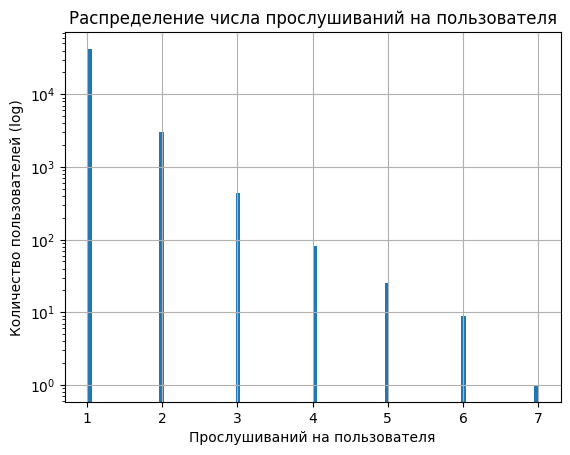

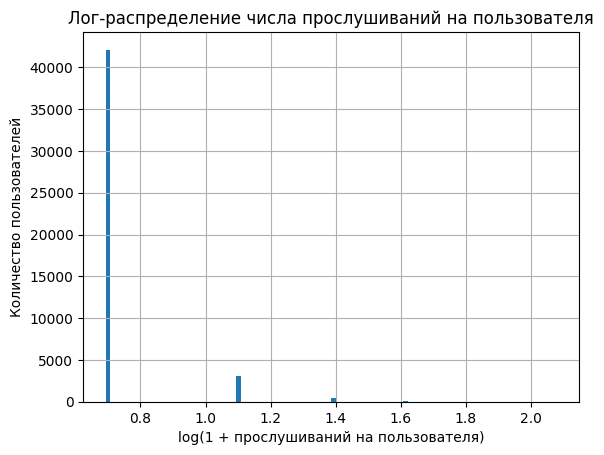

In [7]:
# Распределение количества прослушиваний (интеракций) на пользователя
user_cnt = (
    interactions.groupby("user_id")["track_id"].size().rename("n_events")
)
display(user_cnt.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
user_cnt.hist(bins=100)
plt.yscale("log")
plt.xlabel("Прослушиваний на пользователя")
plt.ylabel("Количество пользователей (log)")
plt.title("Распределение числа прослушиваний на пользователя")
plt.show()

plt.figure()
np.log1p(user_cnt).hist(bins=100)
plt.xlabel("log(1 + прослушиваний на пользователя)")
plt.ylabel("Количество пользователей")
plt.title("Лог-распределение числа прослушиваний на пользователя")
plt.show()


Наиболее популярные треки

In [8]:
def top_by_events(
    interactions,
    catalog_names,
    tracks=None,
    *,
    item_col,
    catalog_type,
    explode_col=None,
    name_col=None,
    top_k=20,
    top_pct=0.01,
):
    """
    Топ сущностей по числу событий.
    """
    if explode_col is None:
        count_series = (
            interactions.groupby(item_col).size().sort_values(ascending=False)
        )
        group_col = item_col
    else:
        merged = interactions.merge(
            tracks[["track_id", explode_col]], on="track_id", how="left"
        )
        exploded = merged.explode(explode_col).dropna(subset=[explode_col])
        exploded[explode_col] = pd.to_numeric(
            exploded[explode_col], errors="coerce"
        )
        exploded = exploded.dropna(subset=[explode_col])
        exploded[explode_col] = exploded[explode_col].astype("int64")
        count_series = (
            exploded.groupby(explode_col).size().sort_values(ascending=False)
        )
        group_col = explode_col

    top = count_series.head(top_k).reset_index()
    top.columns = [group_col, "n_events"]

    catalog_ref = catalog_names.loc[
        catalog_names["type"] == catalog_type, ["id", "name"]
    ]
    top = top.merge(
        catalog_ref.rename(columns={"id": group_col}),
        on=group_col,
        how="left",
    )
    out_name = name_col if name_col else f"{catalog_type}_name"
    top = top.rename(columns={"name": out_name})

    n_top = max(1, int(top_pct * len(count_series)))
    share = count_series.head(n_top).sum() / count_series.sum()
    return top, count_series, share


# Наиболее популярные треки
top_tracks, track_pop, share_top1pct = top_by_events(
    interactions,
    catalog_names,
    item_col="track_id",
    catalog_type="track",
    top_k=20,
    top_pct=0.01,
)
display(top_tracks)
print(f"Share of events covered by top 1% tracks: {share_top1pct:.2%}")

,track_id,n_events,track_name
0,33311009,25,Believer
1,35505245,25,I Got Love
2,37384,24,Zombie
3,50685843,23,Кукла колдуна
4,795836,23,Shape Of My Heart
5,21519270,22,Dancin
6,54798445,22,Прятки
7,148345,21,Californication
8,66869588,21,Краш
9,328683,21,Bring Me To Life


Share of events covered by top 1% tracks: 7.62%


Наиболее популярные жанры

In [9]:
top_genres, genre_pop, share_top1pct_genres = top_by_events(
    interactions,
    catalog_names,
    tracks=tracks,
    item_col="genres",
    catalog_type="genre",
    explode_col="genres",
    name_col="genre_name",
    top_k=20,
    top_pct=0.01,
)
display(top_genres)
print(
    f"Share of events covered by top 1% genres: {share_top1pct_genres:.2%}"
)


,genres,n_events,genre_name
0,11,12501,pop
1,75,8397,rap
2,102,6947,allrock
3,20,6034,ruspop
4,3,5662,rusrap
5,68,4560,electronics
6,16,3739,dance
7,14,2907,rock
8,47,2891,metal
9,2,2889,rusrock


Share of events covered by top 1% genres: 14.76%


Треки, которые никто не прослушал

In [10]:
listened_tracks = set(interactions["track_id"].unique().tolist())
all_tracks = set(tracks["track_id"].unique().tolist())
never_listened = sorted(list(all_tracks - listened_tracks))

print(
    "Tracks never listened:",
    len(never_listened),
    f"({len(never_listened)/len(all_tracks):.2%} of catalog tracks)",
)

track_name_map = (
    catalog_names.loc[catalog_names["type"] == "track", ["id", "name"]]
    .set_index("id")["name"]
    .to_dict()
)
display(
    pd.DataFrame({
        "track_id": never_listened[:20],
        "track_name": [track_name_map.get(t) for t in never_listened[:20]],
    })
)

Tracks never listened: 0 (0.00% of catalog tracks)


,track_id,track_name


### **Преобразование данных**

In [11]:
track_names = (
    catalog_names.loc[catalog_names["type"] == "track", ["id", "name"]]
    .rename(columns={"id": "track_id", "name": "track_name"})
)
items = tracks.merge(track_names, on="track_id", how="left")

events = (
    interactions.sort_values(["user_id", "started_at"])
    .reset_index(drop=True)
)

# Label encoding for user_id and track_id (fit on full events for consistent indices)
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
user_encoder.fit(events["user_id"])
item_encoder.fit(events["track_id"])
events["user_id_enc"] = user_encoder.transform(events["user_id"])
events["track_id_enc"] = item_encoder.transform(events["track_id"])
items["track_id_enc"] = item_encoder.transform(items["track_id"])

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())

items: (32623, 6)
events: (50000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,147,"[13, 99422]",[90],"[59, 102]",Action,0
1,553,"[48, 463, 473, 9967, 10655, 37052, 88412, 8841...",[451],"[11, 68, 74]",Boom Boom Pow,1
2,562,"[48, 9967, 11309, 11317, 67947, 72275, 88412, ...",[451],"[11, 68]",I Gotta Feeling,2
3,859,"[76, 6411, 6552, 88496, 2003157, 2580920, 3062...",[764],"[14, 102]",Tutti Frutti,3
4,861,"[76, 134, 179, 6411, 7949, 8154, 88496, 91334,...",[764],"[14, 33, 74, 102]",Long Tall Sally,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,69,465060,235,2022-05-10,0,2145
1,71,9358290,263,2022-03-19,1,6779
2,71,32159785,1026,2022-08-22,1,14264
3,90,606309,51,2022-07-13,2,2567
4,90,43526320,320,2022-09-29,2,19973


### **Сохранение данных**

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [12]:
# Сохранение данных (локально) + (опционально) в S3
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET_NAME")
s3_access_key = os.environ.get("AWS_ACCESS_KEY_ID")
s3_secret_access_key = os.environ.get("AWS_SECRET_ACCESS_KEY")

items_out = OUTPUT_DIR / "items.parquet"
events_out = OUTPUT_DIR / "events.parquet"

items.to_parquet(items_out, index=False)
events.to_parquet(events_out, index=False)

encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "wb") as f:
    pickle.dump({"user_encoder": user_encoder, "item_encoder": item_encoder}, f)

print("Saved locally:")
print(" -", items_out.resolve())
print(" -", events_out.resolve())

# if s3_bucket and s3_access_key and s3_secret_access_key:
#     s3_prefix = "recsys/data"
#     client = boto3.client(
#         "s3",
#         aws_access_key_id=s3_access_key,
#         aws_secret_access_key=s3_secret_access_key,
#     )
#     client.upload_file(
#         str(items_out), s3_bucket, f"{s3_prefix}/items.parquet"
#     )
#     client.upload_file(
#         str(events_out), s3_bucket, f"{s3_prefix}/events.parquet"
#     )
#     print(f"Uploaded to s3://{s3_bucket}/{s3_prefix}/")
# else:
#     print(
#         "S3 creds not set (S3_BUCKET_NAME, AWS_ACCESS_KEY_ID, AWS_SECRET_ACCESS_KEY)"
#         " -> skip S3 upload"
#     )


Saved locally:
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\items.parquet
 - C:\Users\Selecty\Desktop\leroy\yandex-mle\mle-project-sprint-4-v001\recsys\data\events.parquet


### **Очистка памяти**

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [13]:
# Очистка памяти: удаляем датафреймы этапов 1–2, данные для моделирования будут загружены из S3
del tracks, catalog_names, interactions, items, events
gc.collect()

8687

### **=== ЭТАП 3 ===**

**Загрузка данных**

Если необходимо, то загружаем items.parquet, events.parquet.

In [14]:
# Загрузка подготовленных данных
items_path = OUTPUT_DIR / "items.parquet"
events_path = OUTPUT_DIR / "events.parquet"

items = pd.read_parquet(items_path)
events = pd.read_parquet(events_path)

print("items:", items.shape)
print("events:", events.shape)
display(items.head())
display(events.head())


items: (32623, 6)
events: (50000, 6)


,track_id,albums,artists,genres,track_name,track_id_enc
0,147,"[13, 99422]",[90],"[59, 102]",Action,0
1,553,"[48, 463, 473, 9967, 10655, 37052, 88412, 8841...",[451],"[11, 68, 74]",Boom Boom Pow,1
2,562,"[48, 9967, 11309, 11317, 67947, 72275, 88412, ...",[451],"[11, 68]",I Gotta Feeling,2
3,859,"[76, 6411, 6552, 88496, 2003157, 2580920, 3062...",[764],"[14, 102]",Tutti Frutti,3
4,861,"[76, 134, 179, 6411, 7949, 8154, 88496, 91334,...",[764],"[14, 33, 74, 102]",Long Tall Sally,4


,user_id,track_id,track_seq,started_at,user_id_enc,track_id_enc
0,69,465060,235,2022-05-10,0,2145
1,71,9358290,263,2022-03-19,1,6779
2,71,32159785,1026,2022-08-22,1,14264
3,90,606309,51,2022-07-13,2,2567
4,90,43526320,320,2022-09-29,2,19973


### **Разбиение данных**

Разбиваем данные на тренировочную, тестовую выборки.

In [15]:
SPLIT_DATE = "2022-12-16"
train_events = events[events["started_at"] < SPLIT_DATE]
test_events = events[events["started_at"] >= SPLIT_DATE]
print("train_events:", train_events.shape)
print("test_events:", test_events.shape)

train_events: (46817, 6)
test_events: (3183, 6)


### **RecSys**

### **Топ популярных**

Рассчитаем рекомендации как топ популярных.

In [ ]:
# Top Popular: robust popularity = reach (users) × engagement (track_seq)
# lower seq = stronger signal
TOP_N = 100

# Per-user max track_seq so engagement is relative to each user's history (early vs late)
max_seq_per_user = (
    train_events.groupby("user_id")["track_seq"].transform("max").clip(lower=1)
)
_train = train_events.assign(
    engagement=1.0 / (1.0 + train_events["track_seq"] / max_seq_per_user)
)

item_popularity = (
    _train.groupby("track_id")
    .agg(users=("user_id", "nunique"), avg_engagement=("engagement", "mean"))
    .reset_index()
    .rename(columns={"track_id": "item_id"})
)

# Scale
scaler = MinMaxScaler()
item_popularity[["users_norm", "avg_engagement_norm"]] = scaler.fit_transform(
    item_popularity[["users", "avg_engagement"]]
)
item_popularity["popularity_score"] = (
    item_popularity["users_norm"] * item_popularity["avg_engagement_norm"]
)
item_popularity = item_popularity.sort_values("popularity_score", ascending=False)

item_popularity_top = item_popularity.head(TOP_N)[['item_id', 'popularity_score']].rename(
    columns={'popularity_score': 'score'}
).reset_index(drop=True)

item_popularity_top.to_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet", index=False)
print(f"Saved cold_recs to parquet: {len(item_popularity_top)} rows")

Saved cold_recs to parquet: 100 rows


In [27]:
# Display TOPN cold_start recs
top_items_with_name = item_popularity.merge(
    items[["track_id", "track_name"]].rename(columns={"track_id": "item_id"}),
    on="item_id",
    how="left",
)

top_items_with_name = top_items_with_name[
    ["item_id", "track_name", "users", "avg_engagement", "popularity_score"]
]

with pd.option_context("display.max_rows", 10):
    display(top_items_with_name.head(10))

,item_id,track_name,users,avg_engagement,popularity_score
0,10216,Wind Of Change,15,0.629259,0.151151
1,4185,Just Dance,6,0.741049,0.100669
2,630670,"You're Gonna Go Far, Kid",13,0.595862,0.096084
3,110138,Формалин,5,0.776231,0.092290
4,23559960,Stressed Out,15,0.578173,0.091413
5,37384,Zombie,24,0.543610,0.083779
6,631623,Sweet Dreams (Are Made of This),13,0.581280,0.081468
7,732388,ариведерчи,10,0.600589,0.075616
8,2008,Running To The Edge Of The World,3,0.950611,0.075276
9,234701,U Can't Touch This,7,0.650004,0.075175


### **Персональные**

Рассчитаем персональные рекомендации.

In [28]:
# 3.2 Personal Recommendations (ALS)

# Prepare data for ALS: create user-item matrix
# Load encoders saved during data preparation (Stage 1)
encoders_path = OUTPUT_DIR / "encoders.pkl"
with open(encoders_path, "rb") as f:
    encoders = pickle.load(f)
user_encoder = encoders["user_encoder"]
item_encoder = encoders["item_encoder"]
unique_users = user_encoder.classes_
unique_items = item_encoder.classes_

# Add encoded columns for direct matrix construction
events_train = train_events.copy()
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train["track_id"])
events_train["rating"] = 1.0  # Binary implicit feedback

# Create CSR matrix directly
user_item_matrix = scipy.sparse.csr_matrix(
    (
        events_train["rating"].values,
        (events_train["user_id_enc"].values, events_train["item_id_enc"].values),
    ),
    shape=(len(unique_users), len(unique_items)),
    dtype=np.float32,
)

print(f"User-item matrix shape: {user_item_matrix.shape}")
print(f"Non-zero entries: {user_item_matrix.nnz}")

# Train ALS model
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.1,
    iterations=15,
    random_state=RANDOM_STATE,
    num_threads=4
)

print("Training ALS model...")
als_model.fit(user_item_matrix)
print("ALS model trained successfully")

# Generate recommendations for train users (candidates for CatBoost ranker)
train_users_recommend = train_events["user_id"].unique()
user_ids_encoded = user_encoder.transform(train_users_recommend)

item_ids_enc, als_scores = als_model.recommend(
    user_ids_encoded,
    user_item_matrix[user_ids_encoded],
    filter_already_liked_items=True,
    N=TOP_N
)

# Convert to DataFrame
als_recommendations = pd.DataFrame({
    "user_id_enc": user_ids_encoded,
    "item_id_enc": [row.tolist() for row in item_ids_enc],
    "score": [row.tolist() for row in als_scores],
})
als_recommendations = als_recommendations.explode(
    ["item_id_enc", "score"], ignore_index=True)
als_recommendations["item_id_enc"] = als_recommendations["item_id_enc"].astype(np.int64)
als_recommendations["score"] = als_recommendations["score"].astype(np.float64)

# Map encoded IDs back to original IDs
als_recommendations["user_id"] = user_encoder.inverse_transform(
    als_recommendations["user_id_enc"])
als_recommendations["item_id"] = item_encoder.inverse_transform(
    als_recommendations["item_id_enc"])
als_recommendations = als_recommendations.drop(
    columns=["user_id_enc", "item_id_enc"])

# Add rank per user
als_recommendations["rank"] = als_recommendations.groupby("user_id").cumcount() + 1
personal_als = als_recommendations[["user_id", "item_id", "score", "rank"]].copy()
personal_als.to_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet", index=False)
print(f"personal_als: {personal_als.shape}, saved to {RECOMMENDATIONS_DIR / 'personal_als.parquet'}")
display(personal_als.head(10))

User-item matrix shape: (45693, 32623)
Non-zero entries: 46817


c:\Users\Selecty\anaconda3\envs\recsys\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\Selecty\anaconda3\envs\recsys\Lib\site-packages\implicit\cpu\als.py:95: RuntimeWarning: Intel MKL BLAS is configured to use 12 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


Training ALS model...


100%|██████████| 15/15 [00:00<00:00, 17.35it/s]


ALS model trained successfully
personal_als: (4283800, 4), saved to recsys\recommendations\personal_als.parquet


,user_id,item_id,score,rank
0,69,78426489,0.000018,1
1,69,694683,0.000015,2
2,69,16298499,0.000014,3
3,69,55909411,0.000013,4
4,69,29544272,0.000012,5
5,69,3581309,0.000008,6
6,69,65765,0.000007,7
7,69,9047114,0.000007,8
8,69,25995209,0.000007,9
9,69,24663745,0.000006,10


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [29]:
# Load and Prepare Items for Content Recommendations (use items for DEBUG subset)
items_content = items[
    items["genres"].notna() & (items["genres"].apply(len) > 0)
].copy()

# Sort by track_id
items_content = items_content.sort_values("track_id").reset_index(drop=True)

# Create encoded index
items_content["track_id_enc"] = range(len(items_content))

print(f"Content items (tracks with genres): {len(items_content)}")
items_content.head()


Content items (tracks with genres): 32591


,track_id,albums,artists,genres,track_name,track_id_enc
0,147,"[13, 99422]",[90],"[59, 102]",Action,0
1,553,"[48, 463, 473, 9967, 10655, 37052, 88412, 8841...",[451],"[11, 68, 74]",Boom Boom Pow,1
2,562,"[48, 9967, 11309, 11317, 67947, 72275, 88412, ...",[451],"[11, 68]",I Gotta Feeling,2
3,859,"[76, 6411, 6552, 88496, 2003157, 2580920, 3062...",[764],"[14, 102]",Tutti Frutti,3
4,861,"[76, 134, 179, 6411, 7949, 8154, 88496, 91334,...",[764],"[14, 33, 74, 102]",Long Tall Sally,4


In [30]:
# Build Genre Vocabulary
def get_genres(items):
    """Build genre frequency table from items. Returns DataFrame with genre_id (index), frequency, and score (normalized)."""
    freq = {}
    for genres_list in items["genres"]:
        for gid in genres_list:
            freq[gid] = freq.get(gid, 0) + 1
    genres = pd.DataFrame({"frequency": freq}).rename_axis("genre_id")
    return genres

genres = get_genres(items_content)
print(f"Unique genres: {len(genres)}")
genres["score"] = genres["frequency"] / genres["frequency"].sum()
genres.sort_values("score", ascending=False).head(10)

Unique genres: 151


,frequency,score
genre_id,,
11,7381,0.134430
75,5411,0.098550
102,4209,0.076658
3,3591,0.065403
20,3359,0.061177
68,3302,0.060139
16,2182,0.039741
47,2038,0.037118
44,1768,0.032200


In [31]:
# Build Track--Genre CSR Matrix
def get_track2genre_matrix(genres, items):
    """Build sparse (num_tracks, num_genres) matrix. Entry = 1 if track has genre."""
    genre_ids = sorted(genres.index.tolist())
    genre2idx = {gid: i for i, gid in enumerate(genre_ids)}
    num_genres = len(genre_ids)
    num_tracks = len(items)

    row_idx, col_idx, data = [], [], []
    for i, genres_list in enumerate(items["genres"]):
        for gid in genres_list:
            if gid in genre2idx:
                row_idx.append(i)
                col_idx.append(genre2idx[gid])
                data.append(1)

    matrix = scipy.sparse.csr_matrix(
        (data, (row_idx, col_idx)),
        shape=(num_tracks, num_genres)
    )
    return normalize(matrix, norm="l1", axis=1)

track_genre_matrix = get_track2genre_matrix(genres, items_content)
print(f"Track-Genre matrix shape: {track_genre_matrix.shape}")

Track-Genre matrix shape: (32591, 151)


In [32]:
def recommend_similar_tracks(track_id, items, track_genre_matrix, k=5):
    """Return top-k similar tracks by genre cosine similarity."""
    match = items.loc[items["track_id"] == track_id, "track_id_enc"]
    if match.empty:
        return pd.DataFrame()
    track_id_enc = match.values[0]
    target_vector = track_genre_matrix[track_id_enc]
    similarity_scores = cosine_similarity(track_genre_matrix, target_vector).flatten()
    similarity_scores[track_id_enc] = -1  # remove self-match
    top_k_indices = np.argsort(similarity_scores)[-k:][::-1]
    similar_tracks = items[items["track_id_enc"].isin(top_k_indices)].copy()
    # attach scores in order
    enc2score = {i: float(similarity_scores[i]) for i in top_k_indices}
    similar_tracks["similarity"] = similar_tracks["track_id_enc"].map(enc2score)
    return similar_tracks[["track_id", "similarity"]].reset_index(drop=True)

# Demo
sample_track = items_content["track_id"].iloc[0]
recs = recommend_similar_tracks(sample_track, items_content, track_genre_matrix, k=5)
print(f"Similar tracks for track_id={sample_track}:")
recs

Similar tracks for track_id=147:


,track_id,similarity
0,33282,1.0
1,15769687,1.0
2,24327488,1.0
3,43526513,1.0
4,65885510,1.0


In [64]:
# Build content-based recommendations (user seed track -> similar tracks)
TOP_N_CONTENT = 100
# Latest track per user
user_seeds = (
    train_events.sort_values(by=["user_id", "track_seq"], ascending=[True, False])
    .drop_duplicates(subset=["user_id"], keep="first")[["user_id", "track_id"]]
    .rename(columns={"track_id": "seed_track"})
)
seed_tracks = user_seeds["seed_track"].drop_duplicates().values

In [66]:
# Build content-based recommendations (user seed track -> similar tracks)
TOP_N_CONTENT = 100
# Latest track per user
user_seeds = (
    train_events.sort_values(by=["user_id", "track_seq"], ascending=[True, False])
    .drop_duplicates(subset=["user_id"], keep="first")[["user_id", "track_id"]]
    .rename(columns={"track_id": "seed_track"})
)
seed_tracks = user_seeds["seed_track"].drop_duplicates().values
seed_recs = []
for seed_t in tqdm(seed_tracks, desc="Content recs"):
    recs = recommend_similar_tracks(seed_t, items_content, track_genre_matrix, k=TOP_N_CONTENT)
    if recs.empty:
        continue
    for r, (_, row) in enumerate(recs.iterrows(), 1):
        seed_recs.append({"seed_track": seed_t, "rank": r, "item_id": row["track_id"], "score": row["similarity"]})
if len(seed_recs) > 0:
    seed_recs_df = pd.DataFrame(seed_recs)
    content_recs = user_seeds.merge(seed_recs_df, on="seed_track")[["user_id", "item_id", "score", "rank"]]
else:
    content_recs = pd.DataFrame(columns=["user_id", "item_id", "score", "rank"])
content_recs.to_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet", index=False)
print(f"content_recs: {content_recs.shape}, saved to parquet")
test_users_content = content_recs.loc[content_recs["user_id"].isin(test_events["user_id"])]["user_id"].nunique()
print(f"test_users_content: {test_users_content}")

Content recs:   0%|          | 0/28607 [00:00<?, ?it/s]

Content recs: 100%|██████████| 28607/28607 [03:57<00:00, 120.28it/s]


content_recs: (4280800, 4), saved to parquet
test_users_content: 299


In [67]:
# Generate similar tracks for all items and save to parquet
K_SIMILAR = 100
similar_rows = []
track_ids_content = items_content["track_id"].tolist()
for track_id in tqdm(track_ids_content, desc="Similar tracks"):
    recs = recommend_similar_tracks(track_id, items_content, track_genre_matrix, k=K_SIMILAR)
    if recs.empty:
        continue
    for rank, (_, row) in enumerate(recs.iterrows(), start=1):
        similar_rows.append({
            "track_id": track_id,
            "similar_track_id": row["track_id"],
            "score": row["similarity"],
            "rank": rank,
        })
similar_tracks_all = pd.DataFrame(similar_rows)
similar_tracks_all.to_parquet(RECOMMENDATIONS_DIR / "similar.parquet", index=False)
print(f"Saved similar.parquet: {len(similar_tracks_all)} rows")

Similar tracks: 100%|██████████| 32591/32591 [04:14<00:00, 128.23it/s]


Saved similar.parquet: 3259100 rows


### Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [92]:
split_date_for_labels = pd.to_datetime("2022-12-23").date()

In [96]:
# User features for ranking
user_activity = train_events.groupby("user_id").size().reset_index(name="user_activity")
user_last_started = train_events.groupby("user_id")["started_at"].max().reset_index(name="user_last_started_at")
ref_date = pd.Timestamp(split_date_for_labels)
user_last_started["days_since_last_user_interaction"] = (
    ref_date - pd.to_datetime(user_last_started["user_last_started_at"])
).dt.days
user_features = user_activity.merge(
    user_last_started[["user_id", "days_since_last_user_interaction"]], on="user_id"
)
days_since_median = user_features["days_since_last_user_interaction"].median()

Фича user_is_cold добавлена далее в проекте

### Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [97]:
# Split test data for labels and final evaluation
test_started = pd.to_datetime(test_events["started_at"]).dt.date
split_mask = test_started < split_date_for_labels
events_train_candidates = test_events.loc[split_mask].copy()
events_test_candidates = test_events.loc[~split_mask].copy()
events_train_candidates["target"] = 1
print(
    f"events_train_candidates: {len(events_train_candidates)}, "
    f"events_test_candidates: {len(events_test_candidates)}"
)

events_train_candidates: 1642, events_test_candidates: 1541


In [98]:
# Candidate pool construction (training)
als_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "personal_als.parquet")
content_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "content_recs.parquet")
cold_recs = pd.read_parquet(RECOMMENDATIONS_DIR / "cold_recs.parquet")

# Expand cold_recs (item_id, score) to (user_id, item_id, score) for cold users
train_user_ids = train_events["user_id"].drop_duplicates()
cold_user_ids = events_train_candidates["user_id"].drop_duplicates()
cold_user_ids = cold_user_ids[~cold_user_ids.isin(train_user_ids)]
if len(cold_user_ids) > 0 and len(cold_recs) > 0:
    cold_users_df = pd.DataFrame({"user_id": cold_user_ids.values, "_k": 1})
    cold_items_df = cold_recs.assign(_k=1)
    cold_recs_expanded = cold_users_df.merge(cold_items_df, on="_k").drop(columns=["_k"])[["user_id", "item_id", "score"]]
else:
    cold_recs_expanded = pd.DataFrame(columns=["user_id", "item_id", "score"])

# Merge on user_id, item_id (outer); keep max score when duplicate
c_als = als_recs[["user_id", "item_id", "score"]].rename(columns={"score": "als_score"})
c_cnt = content_recs[["user_id", "item_id", "score"]].rename(columns={"score": "cnt_score"})
c_cold = cold_recs_expanded.rename(columns={"score": "cold_score"})
candidates = c_als.merge(c_cnt, on=["user_id", "item_id"], how="outer")
candidates = candidates.merge(c_cold, on=["user_id", "item_id"], how="outer")
for col in ["als_score", "cnt_score", "cold_score"]:
    candidates[col] = candidates[col].fillna(0)
candidates["score"] = candidates[["als_score", "cnt_score", "cold_score"]].max(axis=1)

# Merge user features (cold users: user_activity=0, user_is_cold=1, days_since=median)
candidates = candidates.merge(user_features, on="user_id", how="left")
candidates["user_activity"] = candidates["user_activity"].fillna(0).astype(int)
candidates["user_is_cold"] = (~candidates["user_id"].isin(train_events["user_id"])).astype(int)
candidates["days_since_last_user_interaction"] = candidates["days_since_last_user_interaction"].fillna(days_since_median)
display(candidates)

,user_id,item_id,als_score,cnt_score,cold_score,score,user_activity,days_since_last_user_interaction,user_is_cold
0,69,78426489.0,0.000018,0.0,0.000000,0.000018,1,227.0,0
1,69,694683.0,0.000015,0.0,0.000000,0.000015,1,227.0,0
2,69,16298499.0,0.000014,0.0,0.000000,0.000014,1,227.0,0
3,69,55909411.0,0.000013,0.0,0.000000,0.000013,1,227.0,0
4,69,29544272.0,0.000012,0.0,0.000000,0.000012,1,227.0,0
...,...,...,...,...,...,...,...,...,...
8697817,1374571,109443.0,0.000000,0.0,0.036545,0.036545,0,101.0,1
8697818,1374571,137670.0,0.000000,0.0,0.036539,0.036539,0,101.0,1
8697819,1374571,512793.0,0.000000,0.0,0.036389,0.036389,0,101.0,1
8697820,1374571,41920901.0,0.000000,0.0,0.036255,0.036255,0,101.0,1


In [99]:
# Target construction: 1 if user interacted in events_train_candidates, 0 otherwise
events_labels_target = events_train_candidates[["user_id", "track_id"]].drop_duplicates().rename(
    columns={"track_id": "item_id"})
events_labels_target["target"] = 1
candidates = candidates.merge(
    events_labels_target,
    on=["user_id", "item_id"],
    how="left"
)
candidates["target"] = candidates["target"].fillna(0).astype(int)

# Keep only users with at least one positive; sample 4 negatives per user
candidates_to_sample = candidates.groupby("user_id").filter(lambda x: x["target"].sum() > 0)
positives = candidates_to_sample.query("target == 1")
negatives = (
    candidates_to_sample.query("target == 0")
    .groupby("user_id")
    .apply(lambda x: x.sample(min(4, len(x)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
candidates_for_train = pd.concat([positives, negatives], ignore_index=True)
print(f"candidates_for_train: {len(candidates_for_train)}, positives: {len(positives)}")

candidates_for_train: 40, positives: 8


In [100]:
# Feature engineering & 5. Train CatBoost ranking model
features = ["cold_score", "als_score", "cnt_score", "user_activity", "user_is_cold", "days_since_last_user_interaction"]
X = candidates_for_train[features].fillna(0)
y = candidates_for_train["target"]

model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    verbose=False,
)
model.fit(X, y)
print("CatBoost ranking model trained")

CatBoost ranking model trained


In [101]:
# Candidate pool (inference): ALS + Content + Cold for events_test_candidates users
test_candidates_users = events_test_candidates["user_id"].unique()
c_als = als_recs[als_recs["user_id"].isin(test_candidates_users)][["user_id", "item_id", "score"]].rename(columns={"score": "als_score"})
c_cnt = content_recs[content_recs["user_id"].isin(test_candidates_users)][["user_id", "item_id", "score"]].rename(columns={"score": "cnt_score"})
cold_test_users = pd.Series(test_candidates_users)[~pd.Series(test_candidates_users).isin(train_events["user_id"])]
if len(cold_test_users) > 0 and len(cold_recs) > 0:
    cold_users_df = pd.DataFrame({"user_id": cold_test_users.values, "_k": 1})
    cold_items_df = cold_recs.assign(_k=1)
    c_cold = cold_users_df.merge(cold_items_df, on="_k").drop(columns=["_k"])[["user_id", "item_id", "score"]].rename(columns={"score": "cold_score"})
else:
    c_cold = pd.DataFrame(columns=["user_id", "item_id", "cold_score"])

# Merge
candidates_to_rank = c_als.merge(c_cnt, on=["user_id", "item_id"], how="outer")
candidates_to_rank = candidates_to_rank.merge(c_cold, on=["user_id", "item_id"], how="outer")
for col in ["als_score", "cnt_score", "cold_score"]:
    candidates_to_rank[col] = candidates_to_rank[col].fillna(0)

# Merge user features (cold users: user_activity=0, user_is_cold=1, days_since=median)
candidates_to_rank = candidates_to_rank.merge(user_features, on="user_id", how="left")
candidates_to_rank["user_activity"] = candidates_to_rank["user_activity"].fillna(0).astype(int)
candidates_to_rank["user_is_cold"] = (~candidates_to_rank["user_id"].isin(train_events["user_id"])).astype(int)
candidates_to_rank["days_since_last_user_interaction"] = candidates_to_rank["days_since_last_user_interaction"].fillna(days_since_median)

In [102]:
# Apply ranking model, sort, top 100 per user
inference_pool = Pool(data=candidates_to_rank[features])
predictions = model.predict_proba(inference_pool)
candidates_to_rank["cb_score"] = predictions[:, 1]

candidates_to_rank = candidates_to_rank.sort_values(
    ["user_id", "cb_score"],
    ascending=[True, False]
)
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1
final_recommendations = candidates_to_rank.query("rank <= 100").copy()
final_recommendations = final_recommendations.rename(columns={"cb_score": "score"})

# Save to recsys/recommendations/recommendations.parquet
final_out = final_recommendations[["user_id", "item_id", "score", "rank"]]
final_out.to_parquet(RECOMMENDATIONS_DIR / "recommendations.parquet", index=False)
print(f"Saved {len(final_out)} rows to {RECOMMENDATIONS_DIR / 'recommendations.parquet'}")

Saved 153300 rows to recsys\recommendations\recommendations.parquet


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [110]:
def recall_precision_at_k(recs_df, gt_dict, users, k):
    recalls, precisions = [], []
    for u in users:
        gt = gt_dict.get(u)
        if not gt:
            continue
        rec_items = (
            recs_df.loc[recs_df["user_id"] == u, "item_id"].head(k).tolist()
        )
        hits = gt & set(rec_items)
        recalls.append(len(hits) / len(gt))
        precisions.append(len(hits) / k)
    if not recalls:
        return np.nan, np.nan
    return float(np.mean(recalls)), float(np.mean(precisions))


def coverage_at_k(recs_df, all_items, k):
    """Fraction of catalog covered by top-k recommendations."""
    rec_items = set(recs_df[recs_df["rank"] <= k]["item_id"])
    return len(rec_items) / len(all_items)


def novelty_for_items(item_ids, item_prob):
    """Average self-information of recommended items given item_prob dict."""
    ps = [item_prob.get(i, 1e-12) for i in item_ids]
    return float(np.mean([-np.log2(p) for p in ps]))

def compute_ndcg(rating: pd.Series, score: pd.Series, k):
    """ подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    """
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(
        np.asarray([rating.to_numpy()]),
        np.asarray([score.to_numpy()]),
        k=k
    )

    return ndcg

def novelty_at_k(recs_df, item_prob, test_users, k):
    """Compute Novelty@K: mean over test users of mean -log2(p) for top-k recommendations."""
    recs_topn = recs_df[recs_df["rank"] <= k].copy()
    recs_topn["item_prob"] = recs_topn["item_id"].map(item_prob).fillna(1e-12)
    recs_topn["neg_log2_p"] = -np.log2(recs_topn["item_prob"])
    novelty_per_user = recs_topn[recs_topn["user_id"].isin(test_users)].groupby("user_id")["neg_log2_p"].mean()
    return float(novelty_per_user.mean()) if len(novelty_per_user) > 0 else np.nan

def ndcg_at_k(recs_df, test_events, test_users, k):
    """Compute NDCG@K: merge recs with test ground truth, compute NDCG per user, return mean."""
    test_pairs = test_events[["user_id", "track_id"]].drop_duplicates().rename(columns={"track_id": "item_id"})
    test_pairs["rating_test"] = 1
    recs_with_rating = recs_df.merge(test_pairs, on=["user_id", "item_id"], how="left")
    recs_with_rating["rating_test"] = recs_with_rating["rating_test"].fillna(0).astype(int)
    ndcg_per_user = (
        recs_with_rating[recs_with_rating["user_id"].isin(test_users)]
        .groupby("user_id")
        .apply(lambda x: compute_ndcg(x["rating_test"], x["score"], k=k))
    )
    return float(ndcg_per_user.dropna().mean()) if len(ndcg_per_user.dropna()) > 0 else np.nan

In [ ]:
# Cold users recs metrics


print(f"Top Popular — cold users only, K={TOP_N}:")
print(f"  Recall@K:    {recall_k_cold:.4f}")
print(f"  Precision@K: {precision_k_cold:.4f}")
print(f"  Coverage@K:  {coverage_k_cold:.4f}")
print(f"  Novelty@K:   {novelty_k_cold:.4f}")

In [ ]:
# Evaluation metrics for Personal ALS recommendations


# Print metrics
print(f"Personal ALS — K={TOP_N}:")
print(f"  Recall@K:    {recall_k_als:.4f}")
print(f"  Precision@K: {precision_k_als:.4f}")
print(f"  Coverage@K:  {coverage_k_als:.4f}")
print(f"  Novelty@K:  {novelty_k_als:.4f}")
print(f"  NDCG@K:     {ndcg_k_als:.4f}")

In [ ]:
# Content based metrics


# Print metrics
print(f"Content-Based (genre) — K={TOP_N_CONTENT}:")
print(f"  Recall@K:    {recall_k_content:.4f}")
print(f"  Precision@K: {precision_k_content:.4f}")
print(f"  Coverage@K:  {coverage_k_content:.4f}")
print(f"  Novelty@K:  {novelty_k_content:.4f}")
print(f"  NDCG@K:     {ndcg_k_content:.4f}")

In [111]:
# Final metrics

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [108]:
# Выводы по проделанной работе (заполните по результатам ваших запусков):
# 1) Какие проблемы данных нашли на Этапе 1 и как исправили?
# 2) Какие инсайты по распределениям на Этапе 2?
# 3) Какой baseline лучше по метрикам и почему?


In [109]:
# Здесь можно добавить финальные таблицы/графики или текстовые выводы.
